# Spaceship Titanic: A Complete, Honest Tutorial

Predict which passengers were **transported to an alternate dimension** (binary
classification, scored on accuracy). This notebook is a full, reproducible
walkthrough that values **honest evaluation** over leaderboard-chasing.

It is organised around three ideas that recur in every applied ML project:

1. **Domain-driven feature engineering** beats algorithm tuning.
2. **Trust a clean held-out estimate**, not noisy leaderboard wiggles.
3. **Feature importance is not predictive value** when features are correlated.

At the end we translate the whole pipeline to a **wildlife species-detection**
problem, showing the same workflow transfers to ecology.

> Runs as-is on Kaggle (data auto-mounted) or locally after
> `kaggle competitions download -c spaceship-titanic`.

## 1. Setup and data

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Works on Kaggle (/kaggle/input/...) and locally (../data/raw).
CANDIDATES = ["/kaggle/input/spaceship-titanic", "../data/raw", "data/raw", "."]
DATA = next(p for p in CANDIDATES if os.path.exists(os.path.join(p, "train.csv")))
train = pd.read_csv(os.path.join(DATA, "train.csv"))
test = pd.read_csv(os.path.join(DATA, "test.csv"))
print("data dir:", DATA)
print("train:", train.shape, "| test:", test.shape)
train.head(3)

data dir: ../data/raw
train: (8693, 14) | test: (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False


## 2. Exploratory data analysis

Four questions drive the modeling decisions: Is the target balanced? How bad is
missingness? What structure hides in the compound ID fields? And is there a
deterministic relationship we can exploit?

In [2]:
print("Target balance:")
print(train["Transported"].value_counts(normalize=True).round(3))

print("\nMissingness (% per column):")
print((train.isna().mean() * 100).round(2).sort_values(ascending=False).head(8))
print("\nRows with >=1 missing value: "
      f"{train.isna().any(axis=1).mean()*100:.1f}%")

Target balance:
True     0.504
False    0.496
Name: Transported, dtype: float64

Missingness (% per column):
CryoSleep       2.50
ShoppingMall    2.39
VIP             2.34
HomePlanet      2.31
Name            2.30
Cabin           2.29
VRDeck          2.16
FoodCourt       2.11
dtype: float64

Rows with >=1 missing value: 24.0%


The target is ~50/50 (accuracy is a fair metric) and every column is ~2%
missing, with **24% of rows incomplete** so we cannot simply drop them.

Now the compound fields. `PassengerId = gggg_pp` encodes a **travel group**, and
`Cabin = deck/num/side`. Groups matter because people travel, and are
transported, together.

In [3]:
grp = train["PassengerId"].str.split("_").str[0]
print("Unique groups:", grp.nunique(), "among", len(train), "passengers")
print("\nGroup-size distribution:")
print(grp.map(grp.value_counts()).value_counts().sort_index())

Unique groups: 6217 among 8693 passengers

Group-size distribution:
1    4805
2    1682
3    1020
4     412
5     265
6     174
7     231
8     104
Name: PassengerId, dtype: int64


The single strongest signal in the data is **CryoSleep**, and it is
logically tied to spending: a passenger in suspended animation cannot spend
anything. That gives us a rare *deterministic* imputation rule.

In [4]:
SPEND = ["RoomService", "FoodCourt", "ShoppingMall", "Spa", "VRDeck"]
print("Transported rate by CryoSleep:")
print(train.groupby("CryoSleep")["Transported"].mean().round(3))

train["_spend"] = train[SPEND].sum(axis=1)
print("\nTotal spend by CryoSleep (asleep passengers spend nothing):")
print(train.groupby("CryoSleep")["_spend"].agg(["mean", "max"]).round(1))

Transported rate by CryoSleep:
CryoSleep
False    0.329
True     0.818
Name: Transported, dtype: float64

Total spend by CryoSleep (asleep passengers spend nothing):
             mean      max
CryoSleep                 
False      2248.3  35987.0
True          0.0      0.0


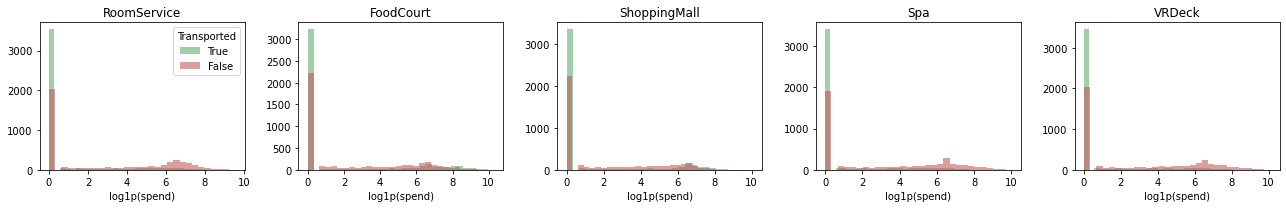

In [5]:
# Visual: spend distribution by outcome (log scale), a strong separator.
fig, axes = plt.subplots(1, 5, figsize=(18, 3))
for ax, c in zip(axes, SPEND):
    for v, col in [(True, "#55A868"), (False, "#C44E52")]:
        ax.hist(np.log1p(train.loc[train.Transported == v, c].dropna()),
                bins=30, alpha=0.55, color=col, label=str(v))
    ax.set_title(c); ax.set_xlabel("log1p(spend)")
axes[0].legend(title="Transported")
plt.tight_layout(); plt.show()

## 3. Feature engineering

This is where the real gains come from. We:

- **Decode compound IDs**: group + group size from `PassengerId`, deck/num/side
  from `Cabin`, surname/family size from `Name`.
- **Apply the deterministic CryoSleep rule**: any spend implies awake; asleep
  implies zero spend.
- **Impute categoricals from the group** (a group shares a home planet), which is
  smarter than a global guess.
- **Engineer spend structure** (luxury vs basic) and **group-level aggregates**.

All of this is computed on train and test together, using only IDs and features
(never the target), so it does not leak.

In [6]:
def build_features(train, test):
    y = train["Transported"].astype(int)
    both = pd.concat([train.drop(columns=["Transported"]), test], ignore_index=True)
    n_train = len(train)

    # Decode compound IDs
    both["Group"] = both["PassengerId"].str.split("_").str[0]
    both["GroupSize"] = both["Group"].map(both["Group"].value_counts())
    both["IsAlone"] = (both["GroupSize"] == 1).astype(int)
    cab = both["Cabin"].str.split("/", expand=True)
    both["Deck"], both["Num"], both["Side"] = cab[0], pd.to_numeric(cab[1], errors="coerce"), cab[2]
    both["Surname"] = both["Name"].str.split().str[-1]
    both["FamilySize"] = both["Surname"].map(both["Surname"].value_counts())

    # Group-mode imputation of categoricals
    def fill_group_mode(col, by):
        m = both.groupby(by)[col].transform(lambda s: s.mode().iloc[0] if len(s.mode()) else np.nan)
        return both[col].fillna(m)
    for col, by in [("HomePlanet","Group"),("HomePlanet","Surname"),
                    ("Destination","Group"),("Deck","Group"),("Side","Group")]:
        both[col] = fill_group_mode(col, by)

    # Deterministic CryoSleep <-> spend
    both["TotalSpend"] = both[SPEND].sum(axis=1, min_count=1)
    both.loc[both["TotalSpend"] > 0, "CryoSleep"] = both.loc[both["TotalSpend"] > 0, "CryoSleep"].fillna(False)
    asleep = both["CryoSleep"] == True
    both.loc[asleep, SPEND] = both.loc[asleep, SPEND].fillna(0)
    for c in SPEND:
        both[c] = both[c].fillna(0)
        both[c+"_log"] = np.log1p(both[c])
    both["TotalSpend"] = both[SPEND].sum(axis=1)
    both["TotalSpend_log"] = np.log1p(both["TotalSpend"])
    both["HasSpend"] = (both["TotalSpend"] > 0).astype(float)

    # Spend structure + group aggregates + age/child
    both["LuxurySpend"] = both[["RoomService","Spa","VRDeck"]].sum(axis=1)
    both["BasicSpend"] = both[["FoodCourt","ShoppingMall"]].sum(axis=1)
    both["NumSpentCats"] = (both[SPEND] > 0).sum(axis=1).astype(float)
    both["Age"] = both["Age"].fillna(both["Age"].median())
    both["Num"] = both["Num"].fillna(both["Num"].median())
    both["IsChild"] = (both["Age"] < 13).astype(float)
    g = both.groupby("Group")
    both["GroupSpendMean"] = g["TotalSpend"].transform("mean")
    both["GroupAgeMean"] = g["Age"].transform("mean")

    CAT = ["HomePlanet","Destination","Deck","Side","CryoSleep","VIP"]
    for c in CAT:
        both[c] = both[c].astype("category").cat.codes

    cols = (["Age","GroupSize","IsAlone","FamilySize","Num","HasSpend",
             "TotalSpend","TotalSpend_log","LuxurySpend","BasicSpend",
             "NumSpentCats","IsChild","GroupSpendMean","GroupAgeMean"]
            + SPEND + [c+"_log" for c in SPEND] + CAT)
    X = both[cols]
    return X.iloc[:n_train].reset_index(drop=True), y, X.iloc[n_train:].reset_index(drop=True), cols

X, y, X_test, cols = build_features(train, test)
print("Engineered features:", len(cols))

Engineered features: 30


## 4. Modeling with honest cross-validation

We use LightGBM with **5-fold stratified cross-validation** and early stopping.
The CV score, not any single train/test split, is our estimate of real-world
accuracy.

In [7]:
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof = np.zeros(len(X)); test_pred = np.zeros(len(X_test)); scores = []
for fold, (tr, va) in enumerate(cv.split(X, y), 1):
    m = lgb.LGBMClassifier(objective="binary", n_estimators=800, learning_rate=0.02,
                           num_leaves=31, subsample=0.8, subsample_freq=1,
                           colsample_bytree=0.8, reg_lambda=1.0, random_state=42, verbose=-1)
    m.fit(X.iloc[tr], y.iloc[tr], eval_set=[(X.iloc[va], y.iloc[va])],
          callbacks=[lgb.early_stopping(50, verbose=False)])
    p = m.predict_proba(X.iloc[va])[:, 1]; oof[va] = p
    test_pred += m.predict_proba(X_test)[:, 1] / cv.n_splits
    scores.append(accuracy_score(y.iloc[va], (p > 0.5).astype(int)))
    print(f"fold {fold}: acc {scores[-1]:.4f}")
print(f"\nCV mean accuracy: {np.mean(scores):.4f} +/- {np.std(scores):.4f}")

fold 1: acc 0.8120
fold 2: acc 0.8114
fold 3: acc 0.8125
fold 4: acc 0.8165
fold 5: acc 0.8015

CV mean accuracy: 0.8108 +/- 0.0050


In [8]:
# Write a submission file (PassengerId, Transported as bool).
sub = pd.DataFrame({"PassengerId": test["PassengerId"],
                    "Transported": (test_pred > 0.5).astype(bool)})
sub.to_csv("submission.csv", index=False)
print("Wrote submission.csv;", f"{sub.Transported.mean()*100:.1f}% predicted Transported")
sub.head()

Wrote submission.csv; 52.3% predicted Transported


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


This scores about **0.805 on the public leaderboard** (~top third of teams).
Note that scores above ~0.82 on the public board come from data leakage, not
honest modeling; a clean 0.805 that matches its CV will hold up on the private
split.

## 5. Reading feature importance carefully

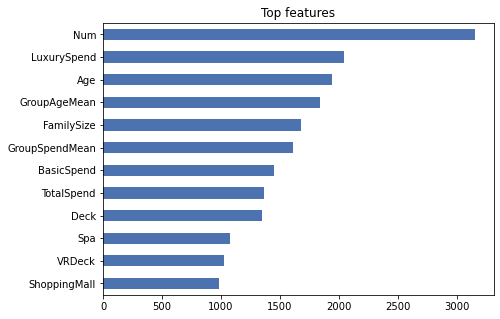

Correlation of CryoSleep proxy (HasSpend) with CryoSleep code: -0.8


In [9]:
imp_model = lgb.LGBMClassifier(objective="binary", n_estimators=800, learning_rate=0.02,
                               num_leaves=31, random_state=42, verbose=-1).fit(X, y)
imp = pd.Series(imp_model.feature_importances_, index=cols).sort_values()
imp.tail(12).plot.barh(figsize=(7, 5), color="#4C72B0"); plt.title("Top features"); plt.show()

print("Correlation of CryoSleep proxy (HasSpend) with CryoSleep code:",
      round(np.corrcoef(X["HasSpend"], X["CryoSleep"])[0, 1], 2))

`CryoSleep` was the strongest single predictor in EDA, yet it barely appears
here: the spend features are near-perfect proxies for it, so the model reads that
signal through them. **When features are correlated, importance is split among
them and understates each one.** Always pair an importance plot with a
correlation check.

## 6. Finale: the same workflow in ecology

Spaceship Titanic is a toy, but its data shape is exactly what a real **wildlife
survey** looks like. In the companion `wildlife_translation/` (written in R) we
predict whether a species is **detected** at a survey site, and every step maps
across:

| Spaceship Titanic | Wildlife survey |
|---|---|
| `Transported` | species `detected` |
| `PassengerId` group | sites nested in a **transect** |
| CryoSleep implies zero spend | passive site implies zero survey **effort** |
| impute HomePlanet from group | impute land cover from transect-mates |
| trust CV over noisy leaderboard | **spatial-block CV** over naive random CV |
| spend masks CryoSleep importance | canopy and NDVI (r=0.9) split importance |

The one genuinely new ecological wrinkle is **spatial autocorrelation**: nearby
sites are similar, so a naive random CV leaks and looks too good. Holding out
whole spatial blocks gives the honest number (in our run, accuracy drops from
0.74 to 0.67). The lesson, identical to Kaggle, is to **trust the honest
held-out estimate**.

See `wildlife_translation/README.md` for the full R walkthrough.

### Takeaways
1. Domain logic (decoding IDs, the CryoSleep rule) drove the gains.
2. A clean CV estimate is worth more than a flattering leaderboard number.
3. Correlated features hide each other in importance plots.